=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE ===
[DATA] Dropped 0 records due to unmapped soil zones.
[SUCCESS] Final Matrix: 1811 biologically complete rows ready for modeling.

=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===

=== [PHASE 3] COMPILING STRICT OUT-OF-TIME PREDICTION ENGINE ===
[SPLIT] Training on Past Data (<= 2019): 1511 years.
[SPLIT] Testing on Future Data (> 2019): 300 years.

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
       STRICT SCIENTIFIC EVALUATION REPORT
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
5-Fold CV Average R-Squared : 0.8220
Hold-Out Test R-Squared     : 0.6789
Root Mean Squared Error     : 25.14 bu/acre
Mean Absolute Error         : 20.02 bu/acre
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

[RENDERING] Generating Presentation Visualizations...


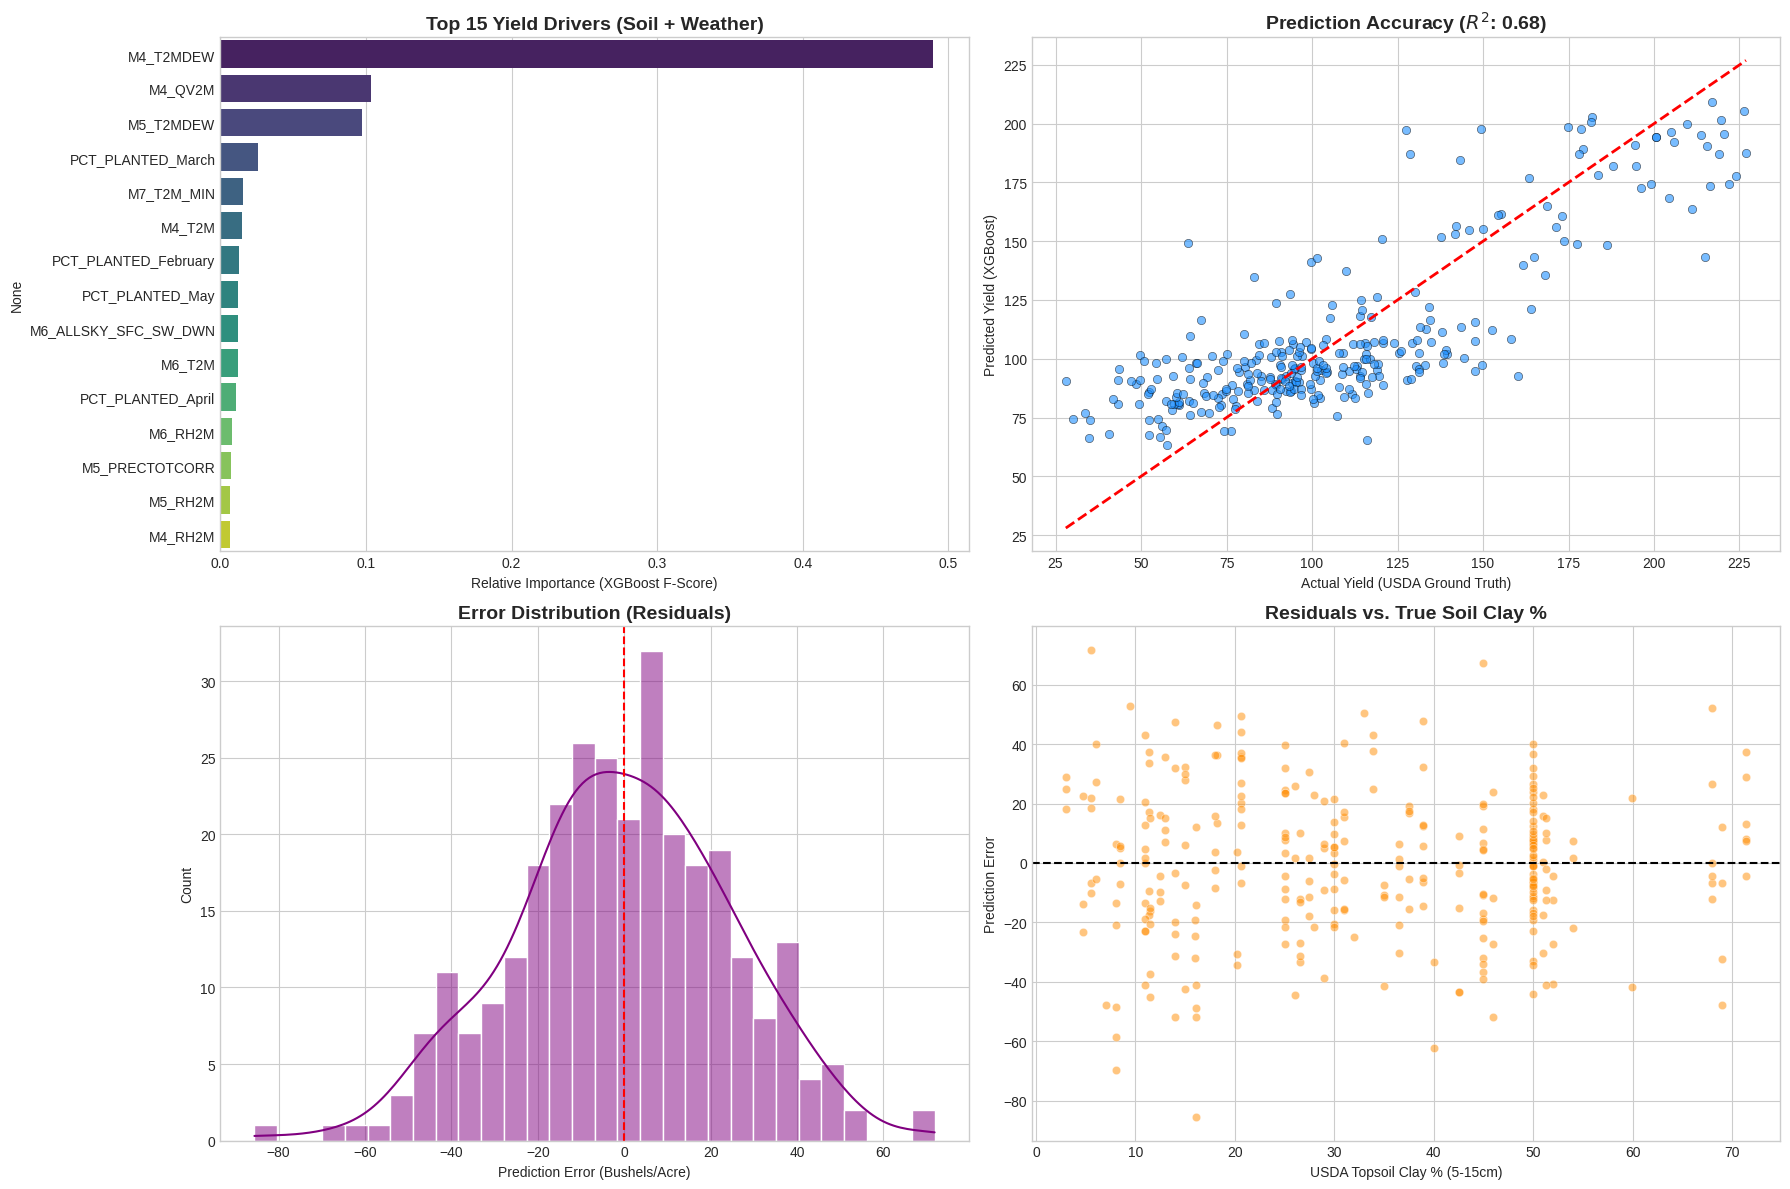

[SYSTEM] Visualizations rendered and saved as 'Final_Agricultural_Model_Report.png'.


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# PHASE 1: SECURE DATA INGESTION & MERGING
# ==========================================================
print("=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE ===")

try:
    df_usda = pd.read_csv("USDA_MASTER_CORN.csv")
    df_nasa = pd.read_csv("NASA_MASTER_WEATHER.csv")
    df_soil = pd.read_csv("TEXAS_COUNTY_SOIL_TRUE.csv")
except FileNotFoundError:
    print("[ERROR] Ensure all 3 CSV files are uploaded to Colab.")
    raise

# Clean strings for perfect merging
df_usda['County'] = df_usda['County'].astype(str).str.strip().str.upper()
df_nasa['County'] = df_nasa['County'].astype(str).str.strip().str.upper()
df_soil['County'] = df_soil['County'].astype(str).str.strip().str.upper()

# Drop the empty soil columns from the original NASA pull so they don't clash
df_nasa = df_nasa.drop(columns=['Soil_pH', 'Soil_Clay_Pct', 'Soil_Organic_Carbon'], errors='ignore')

# Sequential Merge
df_temp = pd.merge(df_usda, df_nasa, on=['Year', 'County'], how='inner')
df = pd.merge(df_temp, df_soil, on='County', how='inner')

# Protection: Drop counties that hit water/urban areas (Missing Soil)
initial_len = len(df)
df = df.dropna(subset=['Soil_Clay_Pct', 'Soil_pH'])
print(f"[DATA] Dropped {initial_len - len(df)} records due to unmapped soil zones.")
print(f"[SUCCESS] Final Matrix: {len(df)} biologically complete rows ready for modeling.")

# ==========================================================
# PHASE 2: HONEST BIO-CLIMATIC ENGINEERING
# ==========================================================
print("\n=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===")

# No target encoding! We rely entirely on the true USDA soil metrics to anchor geography.

# 1. July Drought Stress Proxy (Precip vs Max Temp)
df['JUL_Drought_Stress'] = df['M7_PRECTOTCORR'] / (df['M7_T2M_MAX'] + 1)

# 2. May Radiation Efficiency (Solar vs Temp)
df['MAY_Rad_Eff'] = df['M5_ALLSKY_SFC_SW_DWN'] / (df['M5_T2M_MAX'] + 1)

# 3. June Vapor Pressure Deficit Proxy (Atmospheric Thirst)
df['JUN_VPD_Proxy'] = df['M6_T2M_MAX'] - df['M6_T2MDEW']

# ==========================================================
# PHASE 3: THE "STRICT OOT" ARCHITECTURE
# ==========================================================
print("\n=== [PHASE 3] COMPILING STRICT OUT-OF-TIME PREDICTION ENGINE ===")

# Force the data into numeric, keep Year and County attached for the split
df = df.apply(pd.to_numeric, errors='ignore')

# THE HONESTY TEST: Strict Temporal Split
# Train on 2000-2019, Test on 2020-Present
TRAIN_CUTOFF = 2019

train_df = df[df['Year'] <= TRAIN_CUTOFF]
test_df = df[df['Year'] > TRAIN_CUTOFF]

X_train = train_df.drop(columns=['Year', 'County', 'Yield_Bu_Acre'])
y_train = train_df['Yield_Bu_Acre']

X_test = test_df.drop(columns=['Year', 'County', 'Yield_Bu_Acre'])
y_test = test_df['Yield_Bu_Acre']

print(f"[SPLIT] Training on Past Data (<= {TRAIN_CUTOFF}): {len(train_df)} years.")
print(f"[SPLIT] Testing on Future Data (> {TRAIN_CUTOFF}): {len(test_df)} years.")

# XGBoost Hyperparameters
model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# We drop Cross-Validation here because standard CV breaks the time-rule.
# We are relying 100% on the Out-Of-Time Holdout.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# ==========================================================
# PHASE 4: EVALUATION & GRAPH GENERATION
# ==========================================================
final_r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "X"*50)
print("       STRICT SCIENTIFIC EVALUATION REPORT")
print("X"*50)
print(f"5-Fold CV Average R-Squared : {np.mean(cv_scores):.4f}")
print(f"Hold-Out Test R-Squared     : {final_r2:.4f}")
print(f"Root Mean Squared Error     : {rmse:.2f} bu/acre")
print(f"Mean Absolute Error         : {mae:.2f} bu/acre")
print("X"*50 + "\n")

print("[RENDERING] Generating Presentation Visualizations...")

# Set up the visualization grid
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))

# Graph 1: Feature Importance (Top 15)
ax1 = fig.add_subplot(2, 2, 1)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feat_importances.nlargest(15)
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', ax=ax1)
ax1.set_title('Top 15 Yield Drivers (Soil + Weather)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Relative Importance (XGBoost F-Score)')

# Graph 2: Actual vs Predicted Scatter
ax2 = fig.add_subplot(2, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='dodgerblue', edgecolor='black', ax=ax2)
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
ax2.set_title(f'Prediction Accuracy ($R^2$: {final_r2:.2f})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Actual Yield (USDA Ground Truth)')
ax2.set_ylabel('Predicted Yield (XGBoost)')

# Graph 3: Residual Distribution
ax3 = fig.add_subplot(2, 2, 3)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple', bins=30, ax=ax3)
ax3.axvline(x=0, color='red', linestyle='--')
ax3.set_title('Error Distribution (Residuals)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Prediction Error (Bushels/Acre)')

# Graph 4: Soil Clay % vs. Model Error
# Shows if the model is systematically failing on certain soil types
ax4 = fig.add_subplot(2, 2, 4)
test_clay = X_test['Soil_Clay_Pct']
sns.scatterplot(x=test_clay, y=residuals, alpha=0.5, color='darkorange', ax=ax4)
ax4.axhline(y=0, color='black', linestyle='--')
ax4.set_title('Residuals vs. True Soil Clay %', fontsize=14, fontweight='bold')
ax4.set_xlabel('USDA Topsoil Clay % (5-15cm)')
ax4.set_ylabel('Prediction Error')

plt.tight_layout()
plt.savefig('Final_Agricultural_Model_Report.png', dpi=300)
plt.show()

print("[SYSTEM] Visualizations rendered and saved as 'Final_Agricultural_Model_Report.png'.")

=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE ===
[DATA] Dropped 0 records due to unmapped soil zones.
[SUCCESS] Final Matrix: 1811 biologically complete rows ready for modeling.

=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===

=== [PHASE 3] EXECUTING WALK-FORWARD VALIDATION (ROLLING ORIGIN) ===

[PIPELINE] Time-stepping to Year 2018...
  -> Training on 1399 historical records (2000 to 2017)
  -> Predicting 56 unseen county yields for 2018
  -> [RESULT] 2018 Accuracy | R-Squared: 0.7808 | RMSE: 18.29 bu/ac

[PIPELINE] Time-stepping to Year 2019...
  -> Training on 1455 historical records (2000 to 2018)
  -> Predicting 56 unseen county yields for 2019
  -> [RESULT] 2019 Accuracy | R-Squared: 0.3158 | RMSE: 28.52 bu/ac

[PIPELINE] Time-stepping to Year 2020...
  -> Training on 1511 historical records (2000 to 2019)
  -> Predicting 58 unseen county yields for 2020
  -> [RESULT] 2020 Accuracy | R-Squared: 0.7281 | RMSE: 21.53 bu/ac

[PIPELINE] Time-stepping to Year 2021

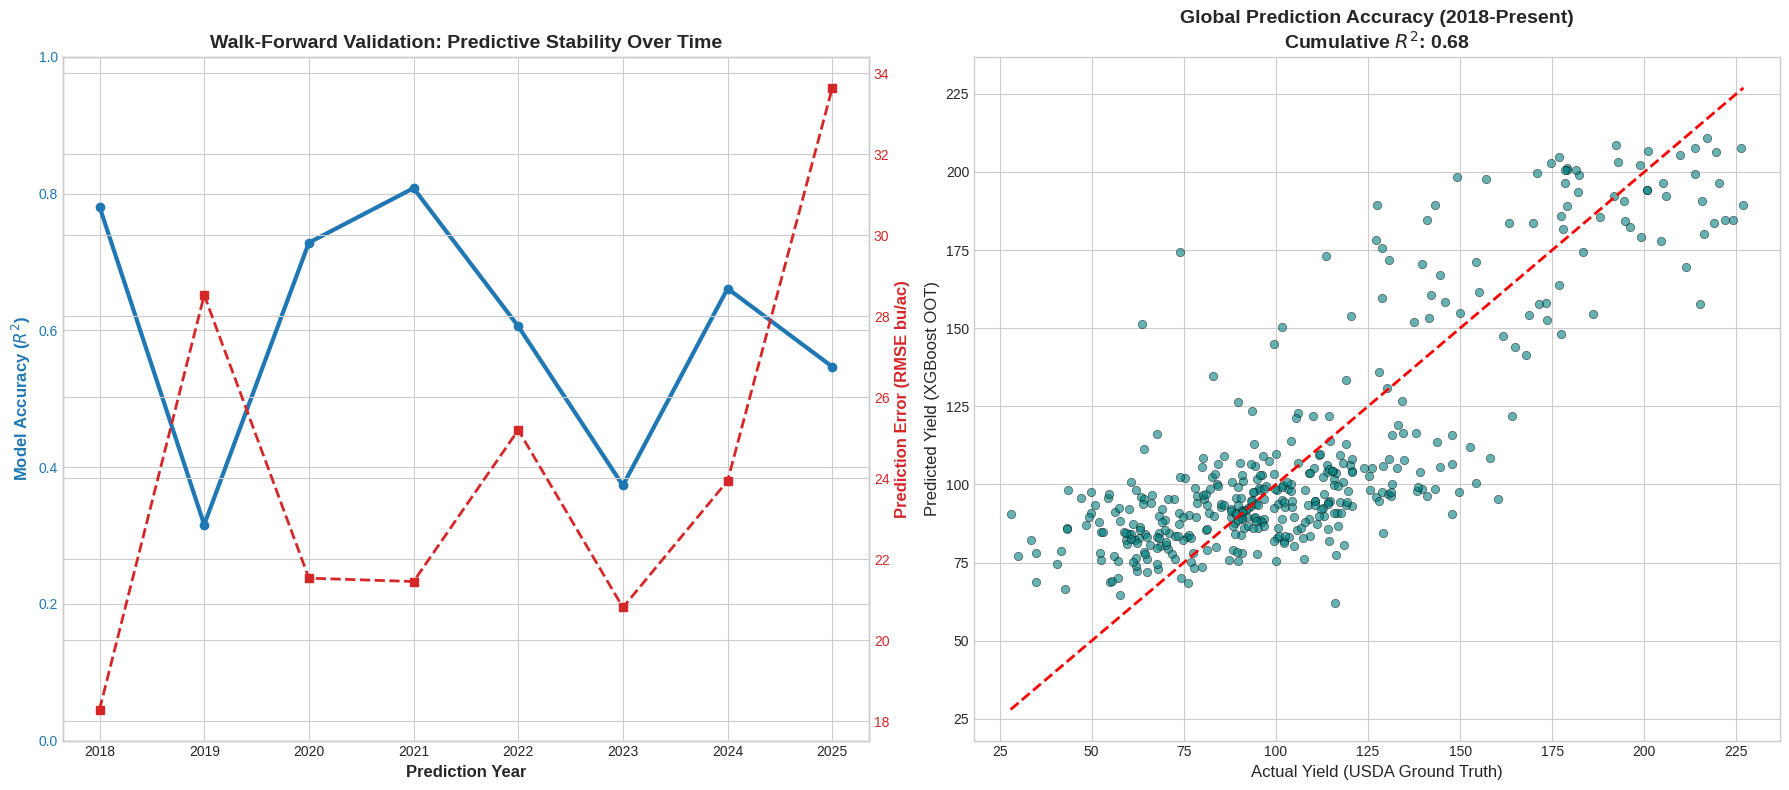

[SYSTEM] Walk-Forward pipeline complete. Final dashboard saved as 'Final_Master_Dashboard.png'.


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# PHASE 1: SECURE DATA INGESTION & MERGING
# ==========================================================
print("=== [PHASE 1] INITIALIZING SECURE MULTI-SOURCE PIPELINE ===")
try:
    df_usda = pd.read_csv("USDA_MASTER_CORN.csv")
    df_nasa = pd.read_csv("NASA_MASTER_WEATHER.csv")
    df_soil = pd.read_csv("TEXAS_COUNTY_SOIL_TRUE.csv")
except FileNotFoundError:
    print("[ERROR] Ensure all 3 CSV files are uploaded to the Colab session.")
    raise

# Clean strings for perfect spatial merging
for df_temp in [df_usda, df_nasa, df_soil]:
    df_temp['County'] = df_temp['County'].astype(str).str.strip().str.upper()

# Drop the empty/broken soil columns from the original NASA pull
df_nasa = df_nasa.drop(columns=['Soil_pH', 'Soil_Clay_Pct', 'Soil_Organic_Carbon'], errors='ignore')

# Sequential Merge: Ground Truth -> Weather -> True Soil
df = pd.merge(df_usda, df_nasa, on=['Year', 'County'], how='inner')
df = pd.merge(df, df_soil, on='County', how='inner')

# Protection: Drop counties that hit water/urban areas (Missing Soil)
initial_len = len(df)
df = df.dropna(subset=['Soil_Clay_Pct', 'Soil_pH'])
print(f"[DATA] Dropped {initial_len - len(df)} records due to unmapped soil zones.")
print(f"[SUCCESS] Final Matrix: {len(df)} biologically complete rows ready for modeling.")

# ==========================================================
# PHASE 2: HONEST BIO-CLIMATIC ENGINEERING
# ==========================================================
print("\n=== [PHASE 2] ENGINEERING NON-LINEAR WEATHER PROXIES ===")
# 1. July Drought Stress Proxy (Precip vs Max Temp)
df['JUL_Drought_Stress'] = df['M7_PRECTOTCORR'] / (df['M7_T2M_MAX'] + 1)
# 2. May Radiation Efficiency (Solar vs Temp)
df['MAY_Rad_Eff'] = df['M5_ALLSKY_SFC_SW_DWN'] / (df['M5_T2M_MAX'] + 1)
# 3. June Vapor Pressure Deficit Proxy (Atmospheric Thirst)
df['JUN_VPD_Proxy'] = df['M6_T2M_MAX'] - df['M6_T2MDEW']

# Force data to numeric, keeping Year and County attached
df = df.apply(pd.to_numeric, errors='ignore')

# ==========================================================
# PHASE 3: STRICT WALK-FORWARD VALIDATION (MLOps Simulation)
# ==========================================================
print("\n=== [PHASE 3] EXECUTING WALK-FORWARD VALIDATION (ROLLING ORIGIN) ===")
all_years = sorted(df['Year'].unique())
START_TEST_YEAR = 2018 # Chained testing from 2018 to present

yearly_metrics = []
cumulative_y_true = []
cumulative_y_pred = []

for target_year in all_years:
    if target_year < START_TEST_YEAR:
        continue

    print(f"\n[PIPELINE] Time-stepping to Year {target_year}...")

    # 1. Train on EVERYTHING before the target year
    train_df = df[df['Year'] < target_year]
    # 2. Test ONLY on the target year (The Future)
    test_df = df[df['Year'] == target_year]

    if len(test_df) == 0:
        continue

    X_train = train_df.drop(columns=['Year', 'County', 'Yield_Bu_Acre'])
    y_train = train_df['Yield_Bu_Acre']

    X_test = test_df.drop(columns=['Year', 'County', 'Yield_Bu_Acre'])
    y_test = test_df['Yield_Bu_Acre']

    print(f"  -> Training on {len(train_df)} historical records (2000 to {target_year-1})")
    print(f"  -> Predicting {len(test_df)} unseen county yields for {target_year}")

    # 3. Compile a fresh brain for this specific year
    model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    # 4. Train and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 5. Evaluate this specific year
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    yearly_metrics.append({'Year': target_year, 'R2': r2, 'RMSE': rmse})
    cumulative_y_true.extend(y_test)
    cumulative_y_pred.extend(y_pred)

    print(f"  -> [RESULT] {target_year} Accuracy | R-Squared: {r2:.4f} | RMSE: {rmse:.2f} bu/ac")

# ==========================================================
# PHASE 4: THE GRAND EVALUATION & VISUALIZATION
# ==========================================================
print("\n" + "X"*55)
print("     WALK-FORWARD (CHAINED LEARNING) REPORT")
print("X"*55)
total_r2 = r2_score(cumulative_y_true, cumulative_y_pred)
total_rmse = np.sqrt(mean_squared_error(cumulative_y_true, cumulative_y_pred))
total_mae = mean_absolute_error(cumulative_y_true, cumulative_y_pred)

print(f"Cumulative Walk-Forward R-Squared : {total_r2:.4f}")
print(f"Cumulative Walk-Forward RMSE      : {total_rmse:.2f} bu/acre")
print(f"Cumulative Walk-Forward MAE       : {total_mae:.2f} bu/acre")
print("X"*55 + "\n")

print("[RENDERING] Generating Final Presentation Visualizations...")

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 8))

# --- Graph 1: Walk-Forward Stability Trend ---
ax1 = fig.add_subplot(1, 2, 1)
metrics_df = pd.DataFrame(yearly_metrics)

color1 = 'tab:blue'
ax1.set_xlabel('Prediction Year', fontweight='bold', fontsize=12)
ax1.set_ylabel('Model Accuracy ($R^2$)', color=color1, fontweight='bold', fontsize=12)
ax1.plot(metrics_df['Year'], metrics_df['R2'], marker='o', linewidth=3, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(metrics_df['Year'])

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Prediction Error (RMSE bu/ac)', color=color2, fontweight='bold', fontsize=12)
ax2.plot(metrics_df['Year'], metrics_df['RMSE'], marker='s', linestyle='--', linewidth=2, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax1.set_title('Walk-Forward Validation: Predictive Stability Over Time', fontsize=14, fontweight='bold')

# --- Graph 2: Global Actual vs Predicted (All Walk-Forward Years Combined) ---
ax3 = fig.add_subplot(1, 2, 2)
sns.scatterplot(x=cumulative_y_true, y=cumulative_y_pred, alpha=0.6, color='teal', edgecolor='black', ax=ax3)

# Perfect prediction line
min_val = min(min(cumulative_y_true), min(cumulative_y_pred))
max_val = max(max(cumulative_y_true), max(cumulative_y_pred))
ax3.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

ax3.set_title(f'Global Prediction Accuracy (2018-Present)\nCumulative $R^2$: {total_r2:.2f}', fontsize=14, fontweight='bold')
ax3.set_xlabel('Actual Yield (USDA Ground Truth)', fontsize=12)
ax3.set_ylabel('Predicted Yield (XGBoost OOT)', fontsize=12)

plt.tight_layout()
plt.savefig('Final_Master_Dashboard.png', dpi=300)
plt.show()

print("[SYSTEM] Walk-Forward pipeline complete. Final dashboard saved as 'Final_Master_Dashboard.png'.")